## Import modules and Packages

## Simulated Annealing (SA)

SA is an optimization algorithm that works by navigating the input space and evaluating the objective function (energy) similarly to hill climbing. The main difference is that SA implements a strategy to avoid getting stuck in local optima.

The general idea is to allow moves to a worse position, but in a structured way. When a candidate solution is selected, the probability of actually moving to the new position is determined by the change in the objective function and by a parameter called **temperature**. When the temperature is high, the chance of performing a jump to a worse state increases, and the opposite happens when the temperature is low. By continuously decreasing the temperature during the execution of the algorithm, it can escape local optima during the first stages (high temperature), but it settles into a position towards the end of the execution (low temperature).

### Probability of Making a Jump

**Case 1:**
$$
\Delta E = E_{current} - E_{next} > 0
$$

It is always advantageous to move to a state with a better objective function. In this case, the probability is $P = 1$.

**Case 2:**
$$
\Delta E = E_{current} - E_{next} < 0
$$

In this case, the probability of taking the step is determined by:

$$
P = e^{-|\Delta E| / T}
$$

**Note:** This formulation applies to a minimization problem. To solve a maximization problem, the only change is that $\Delta E = E_{next} - E_{current}$.

### Temperature Decrease

The way the temperature decreases during the algorithm's execution varies between implementations. This is referred to as the temperature **schedule**, which is a function of time or the number of iterations.

**Note:** $\beta = 1 / T$ is also commonly used in the implementation of the algorithm.

Let's define a larger model, with 100 variables and random weights.

Assume that we are interested at the instance created with random weights $h_{i}, J_{i, j} \sim U[-1, +1]$.

### Problem statement

We pose the Ising problem as the following optimization problem:

$$
\min_{s \in \{ \pm 1 \}^n} H(s) = \min_{s \in \{ \pm 1 \}^n} \sum_{(i, j) \in E(G)} J_{i,j}s_is_j + \sum_{i \in V(G)} h_is_i + \beta
$$

where we optimize over spins $s \in \{ \pm 1 \}^n$, on a constrained graph $G(V,E)$, where the quadratic coefficients are $J_{i,j}$ and the linear coefficients are $h_i$.
We also include an arbitrary offset of the Ising model $\beta$. This ising model can be considered a Sherrington-Kirkpatrick (SK) model, being, therefore, fully connected.

### Raw Data

- Total Instances: 20  
- Varying parameter during solve: num_sweeps (1-1000)  
- Constant parameter: num_reads (resulting in 1000 energies at each sweep step)  

**Goal**: find out how our performance metric behaves with varying num_reads without rerunning the instances from scratch on Simulated Annealing Sampler.  

Original format: `dimod.SampleSet` objects (D-Wave Ocean SDK format)
Example: instance = 0, num_sweeps = 10 contains data formatted as dimod.SampleSet which contains
1000 energies due to 1000 constant reads over the varying num_sweeps parameter  

We are concerned with energies. Hence, we converted the large SampleSet data to `results/all_raw_runs.pkl` to contain 1000 energies per sweep (1-1000) for an instance (0-19) to reduce extensive file size

These Simulated Annealing runs were originally executed using `dwave-neal` on the [QuboNotebooks Repository](https://github.com/JuliaQUBO/QUBONotebooks/blob/main/notebooks_py/5-Benchmarking_python.ipynb).

### Bootstrapping

We are interested in comparing the execution of the algorithm as the schedule step (number of sweeps) varies for different numbers of reads. However, the raw data we have only contains runs with 1000 reads at each schedule step. Bootstrapping can show us what the data was expected to look like had we performed SA with, say, 1, 10, and 100 reads at each sweep.

**Note:** The original data and the bootstrapped data vary in one key aspect. From the original data, we are able to draw absolute values like the minimum and average of the energy reads (1000 in our case). However, the bootstrapping process will give us distributions for these metrics, meaning the "minimum" and "average" energy values for the other numbers of reads are not absolute. Rather, they are expected values according to a distribution and have associated confidence intervals.

In the next cells, we will:
- Load the full raw data for each instance (the 1000 energy reads at each sweep);
- Compute the performance ratio using the SB framework;
- Perform Bootstrapping to infer information about the performance ratio for different numbers of reads.

In [1]:
import os
import pickle
import pandas as pd
import numpy as np


current_path = os.getcwd()
pickle_path = os.path.join(current_path, 'results/')

def load_raw_data(instance_id) -> pd.DataFrame:
    """
        Convert energy sampleset raw data to the format expected by the Stochastic Benchmark Framework

        Args:
            instance_id (int): The instance ID to load the raw data for

        Returns:
            pd.DataFrame: A DataFrame containing the raw data for the given instance
    """
    packed_path = os.path.join(pickle_path, "all_raw_runs.pkl")
    with open(packed_path, "rb") as f:
        all_raw_runs = pickle.load(f)

    sweeps_dict = all_raw_runs[instance_id]
    rows = []

    for sweep, energies in sweeps_dict.items():
        energies = np.array(energies)
        n = len(energies)
        rows.append(pd.DataFrame({
            "instance": np.full(n, instance_id, dtype=int),
            "sweeps":  np.full(n, sweep, dtype=int),
            "energy":  energies,
            "resource": np.ones(n, dtype=int),
        }))

    return pd.concat(rows, ignore_index=True)


Convert energy sampleset raw data to the format expected by the Stochastic Benchmark Framework


In [2]:

results_path = os.path.join(current_path, 'results/')
granular_data_path = os.path.join(current_path, 'granular_data/')

if not os.path.exists(granular_data_path):
    os.makedirs(granular_data_path)

for instance_id in range(20):

    print(f"Compiling data for instance {instance_id}")

    filename = os.path.join(granular_data_path, f'granular_data_{instance_id}.pkl')
    
    raw_data_df = load_raw_data(instance_id)
    pickle.dump(raw_data_df, open(filename, 'wb'))
print(f"converted data for 20 instances saved to ./granular_data/")       

Compiling data for instance 0
Compiling data for instance 1


Compiling data for instance 2
Compiling data for instance 3
Compiling data for instance 4


Compiling data for instance 5
Compiling data for instance 6
Compiling data for instance 7


Compiling data for instance 8
Compiling data for instance 9
Compiling data for instance 10


Compiling data for instance 11
Compiling data for instance 12
Compiling data for instance 13


Compiling data for instance 14
Compiling data for instance 15
Compiling data for instance 16


Compiling data for instance 17
Compiling data for instance 18
Compiling data for instance 19


converted data for 20 instances saved to ./granular_data/


In [3]:
def load_granular_data(instance_id) -> pd.DataFrame:
    """
        Load the granular data, which already is in the format expected by the Stochastic Benchmark Framework, for a given instance

        Args:
            instance_id (int): The instance ID to load the granular data for

        Returns:
            pd.DataFrame: A DataFrame containing the granular data for the given instance
    """
    granular_data_path = os.path.join(current_path, 'granular_data/')
    filename = os.path.join(granular_data_path, f'granular_data_{instance_id}.pkl')
    return pickle.load(open(filename, 'rb'))

### Performance Metric

We are interested in the "performance ratio" metric. In this particular problem, it is calculated as follows:

- First, we sample a subset from the input space and calculate the associated energies. Specifically, we use 1000 random bitstrings in this case.
- The best (minimum) energy found across the random sample is denoted as `minimum`, while the mean energy across the random sampling is denoted as `random`.
- The performance ratio is calculated across an increasing number of sweeps of simulated annealing, where `found` is the best energy found at the current moment in the algorithm's execution.

$$
performance\space ratio = \frac{found - random}{minimum - random}
$$

Even though it is (very) unlikely that we found the best solution during the random sampling, this metric is useful because it gives us a general idea of how good our currently found solution is.

In the following cell we compute the **baselines** for evaluating the Performace ratio during bootstrapping.

In [4]:
import dimod

num_instances = 20
num_reads = 1000
N = 100 # number of variables

def random_energy_for_instance(inst, num_reads=1000):
    """
        Compute the random energy for a given instance

        Args:
            inst (int): The instance ID
            num_reads (int): The number of reads

        Returns:
            float: The random energy
    """
    np.random.seed(inst)  # seed by instance id for reproducibility
    J = np.random.rand(N, N)
    J = np.triu(J, 1)   
    h = np.random.rand(N)
    model_random = dimod.BinaryQuadraticModel.from_ising(h, J, offset=0.0)

    rs = dimod.RandomSampler().sample(model_random, num_reads=num_reads)
    energies = np.asarray(rs.data_vectors["energy"])
    return float(energies.mean())

instance_baselines = {}
for inst in range(num_instances):
    granular = load_granular_data(inst)

    # Global best SA energy across all sweeps and reads for this instance
    best_value = float(granular["energy"].min())

    # Random baseline: mean random energy from RandomSampler on this instance's random Ising model
    random_value = random_energy_for_instance(inst, num_reads=num_reads)

    instance_baselines[inst] = {
        "best_value": best_value,
        "random_value": random_value,
    }

In [5]:
def get_shared_args(instance_id):
    """
        Get the shared arguments for the performance ratio as expected by the Stochastic Benchmark Framework

        Args:
            instance_id (int): The instance ID

        Returns:
            dict: The shared arguments
    """
    default_confidence_level = 68
    baseline = instance_baselines[instance_id]
    return {
        "response_col": "energy",
        "resource_col": "resource",
        "random_value": baseline["random_value"],
        "best_value": baseline["best_value"],
        "confidence_level": default_confidence_level,
    }

The following step **performs Bootstrapping** on the various resample sizes and **computes the Performance Ratio** simultaneously.

In [6]:
import sys
sys.path.append("../../src")

import bootstrap
import success_metrics

checkpoints_path = "checkpoints"
override_bootstrap = False

if not os.path.exists(checkpoints_path):
    os.makedirs(checkpoints_path)

for instance_id in range(20):
  file_path = os.path.join(checkpoints_path, f"bootstrapped_results_inst={instance_id}.pkl")
  if os.path.exists(file_path) and not override_bootstrap:
    continue

  shared_args_for_perf_ratio = get_shared_args(instance_id)

  metric_args = {
    "Response": {"opt_sense": -1}
  }

  def update_rule(bs_params, df):
      return None

  bsParams = bootstrap.BootstrapParameters(
      shared_args=shared_args_for_perf_ratio,
      metric_args=metric_args,
      success_metrics=[success_metrics.Response, success_metrics.PerfRatio],
      bootstrap_iterations=1000,
      update_rule=update_rule
  )

  boots_range = [1, 10, 100, 1000]
  bsParams_iter = bootstrap.BSParams_range_iter()(bsParams, boots_range)

  granular_data_df = load_granular_data(instance_id)
  bs_df = bootstrap.Bootstrap(
    granular_data_df,
    group_on=["instance", "sweeps"],
    bs_params_list=bsParams_iter
  )

  # Add a column for the number of reads identical to boots column
  bs_df["reads"] = bs_df["boots"]

  # save bs_df as pickle
  pickle.dump(bs_df, open(file_path, "wb"))

In [7]:
import stochastic_benchmark as SB

here = os.getcwd()
parameter_names = [
    "sweeps",
    "reads"
]   # reads is a varying parameter alongside sweeps due to bootrapping 

instance_cols = [
    "instance"
]  # indicates how instances should be grouped, default is ['instance']

## Response information
response_key = "PerfRatio"  # Column with the response
response_dir = 1  # whether we want to maximize (1) or minimize (-1), default is 1

## Optimizations informations
recover = True  # Whether we want to read dataframes when available, default is True
reduce_mem = True  # Whether we want to segment bootstrapping and interpolation to reduce memory usage, default is True
smooth = True  # Whether virtual best should be monontonized, default is True

sb = SB.stochastic_benchmark(
    parameter_names=parameter_names,
    here=here,
    instance_cols=instance_cols,
    response_key=response_key,
    response_dir=response_dir,
    smooth=smooth,
)

### Resource

In this analysis, we examine how the performance ratio evolves as the number of sweeps and reads increases during algorithm execution.

The number of sweeps times the number of reads serves as our resource metric. This corresponds to the total time spent in a SA run. The objective is to achieve a high performance ratio while minimizing that product (i.e., using fewer computational resources).

In [8]:
# Load Bootstrap data.
# The data is already boostrapped, but needs to be loaded into memory

shared_args = {
    "response_col": "PerfRatio",
    "resource_col": "resource",
    "response_dir": 1,
    "confidence_level": 68,
}
boots_range = [1, 10, 100, 1000]
bsParams = bootstrap.BootstrapParameters(
    shared_args=shared_args, update_rule=lambda df: None
)
bs_iter_class = bootstrap.BSParams_range_iter()
bsParams_iter = bs_iter_class(bsParams, boots_range)
sb.run_Bootstrap(bsParams_iter)

In [9]:
import interpolate

def resource_fcn(df):
    """
        This is the function that will be used to interpolate the performance ratio across the various resources

        Args:
            df (pd.DataFrame): The DataFrame to interpolate the performance ratio across

        Returns:
            pd.DataFrame: The interpolated performance ratio
    """
    return df["reads"] * df["sweeps"]


iParams = interpolate.InterpolationParameters(resource_fcn, parameters=parameter_names)
sb.run_Interpolate(iParams)

### Repeat Reliability Diagnostics

Use the same best/random baseline convention to define a configurable performance-ratio target, then summarize how many repeats are currently available and how many are required for selected sweeps.

In [10]:
from reliability_analysis import (
    DEFAULT_QUALITY_TARGET,
    attach_quality_thresholds,
    load_selected_granular_runs,
    run_reliability_analysis,
    select_reliability_diagnostics,
)

quality_target = DEFAULT_QUALITY_TARGET
reliability_instances = [0, 1, 2]
reliability_runs = load_selected_granular_runs(current_path, reliability_instances)
reliability_runs = attach_quality_thresholds(
    reliability_runs,
    instance_baselines,
    quality_target=quality_target,
)

sa_reliability = run_reliability_analysis(
    sb,
    reliability_runs,
    quality_target=quality_target,
    relative_error_threshold=0.10,
)
reliability_diagnostics = select_reliability_diagnostics(sa_reliability)
print(
    f"Reliability diagnostics for instances {reliability_instances} "
    f"at performance-ratio target {quality_target:.0%}"
)
reliability_diagnostics

Reliability diagnostics for instances [0, 1, 2] at performance-ratio target 95%


,instance,sweeps,current_resource,current_repeats,required_repeats,additional_repeats_required,p_ci_lower,p_ci_upper,R_c,R_c_ci_lower,R_c_ci_upper,R99,R99_ci_lower,R99_ci_upper,CETS,CETS_ci_lower,CETS_ci_upper,reliability_status,statistically_unresolved
0,0,1,1000,1000,242884,241884,0.000000,0.004617,2404.522302,995.194736,inf,2404.522302,995.194736,inf,2404.522302,995.194736,inf,needs_more_trials,False
112,0,2,2000,1000,242884,241884,0.000000,0.004617,2404.522302,995.194736,inf,2404.522302,995.194736,inf,4809.044604,1990.389472,inf,needs_more_trials,False
178,0,3,3000,1000,242884,241884,0.000000,0.004617,2404.522302,995.194736,inf,2404.522302,995.194736,inf,7213.566906,2985.584208,inf,needs_more_trials,False
199,0,4,4000,1000,94778,93778,0.000581,0.009222,937.162094,497.041900,7918.085805,937.162094,497.041900,7918.085805,3748.648377,1988.167601,3.167234e+04,needs_more_trials,False
542,1,480,480000,1000,1747,747,0.976412,0.991869,1.111295,1.000000,1.229027,1.111295,1.000000,1.229027,533.421595,480.000000,5.899328e+02,needs_more_trials,True
530,1,420,420000,1000,1568,568,0.972739,0.989564,1.159604,1.009352,1.278394,1.159604,1.009352,1.278394,487.033529,423.927877,5.369256e+02,needs_more_trials,True
536,1,450,450000,1000,1568,568,0.972739,0.989564,1.159604,1.009352,1.278394,1.159604,1.009352,1.278394,521.821638,454.208440,5.752774e+02,needs_more_trials,True
532,1,430,430000,1000,1519,519,0.971528,0.988783,1.174840,1.025577,1.294010,1.174840,1.025577,1.294010,505.181075,440.998070,5.564245e+02,needs_more_trials,True
974,2,990,990000,1000,1297,297,0.964367,0.983990,1.259432,1.113833,1.381073,1.259432,1.113833,1.381073,1246.837323,1102.694375,1.367262e+03,needs_more_trials,True
945,2,850,850000,1000,1268,268,0.963189,0.983176,1.272606,1.127352,1.394682,1.272606,1.127352,1.394682,1081.715110,958.249200,1.185480e+03,needs_more_trials,True


### Initial Investigation

For instance 0 of the problem, let's investigate where the performance ratio reaches the extreme values, 0 and 1, across the various numbers of sweeps.

In [11]:
def filter_df_by_reads(df, reads):
    """
        Filter the DataFrame by the number of reads

        Args:
            df (pd.DataFrame): The DataFrame to filter
            reads (int): The number of reads to filter by

        Returns:
            pd.DataFrame: The filtered DataFrame
    """
    return df[df["reads"] == reads]

In [12]:
def find_sweep_with_min_perf_ratio(df) -> tuple[int, float]:
    """
        Find the sweep with the minimum performance ratio

        Args:
            df (pd.DataFrame): The DataFrame to find the minimum performance ratio in

        Returns:
            tuple[int, float]: The sweep with the minimum performance ratio and the minimum performance ratio
    """
    min_perf_ratio = df["Key=PerfRatio"].min()
    return df[df["Key=PerfRatio"] == min_perf_ratio]["sweeps"].values[0], min_perf_ratio

def find_sweep_with_max_perf_ratio(df) -> tuple[int, float]:
    """
        Find the sweep with the maximum performance ratio

        Args:
            df (pd.DataFrame): The DataFrame to find the maximum performance ratio in

        Returns:
            tuple[int, float]: The sweep with the maximum performance ratio and the maximum performance ratio
    """
    max_perf_ratio = df["Key=PerfRatio"].max()
    return df[df["Key=PerfRatio"] == max_perf_ratio]["sweeps"].values[0], max_perf_ratio

In [13]:
bootstrapped_data_path = os.path.join(checkpoints_path, f'bootstrapped_results_inst=0.pkl')
bootstrapped_data = pickle.load(open(bootstrapped_data_path, 'rb'))

print(f"{'Reads':<20}|{'Min Perf Ratio':<20}|{'At':<20}|{'Max Perf Ratio':<20}|{'At':<20}")
print("-"*20 + "|" + "-"*20 + "|" + "-"*20 + "|" + "-"*20 + "|" + "-"*20)

for read_size in [1000, 100, 10, 1]:
    df = filter_df_by_reads(bootstrapped_data, read_size)
    min_perf_ratio_sweep, min_perf_ratio = find_sweep_with_min_perf_ratio(df)
    max_perf_ratio_sweep, max_perf_ratio = find_sweep_with_max_perf_ratio(df)
    print(f"{df['reads'].values[0]:<20}|{min_perf_ratio:<20}|{min_perf_ratio_sweep:<20}|{max_perf_ratio:<20}|{max_perf_ratio_sweep:<20}")
    print("-"*20 + "|" + "-"*20 + "|" + "-"*20 + "|" + "-"*20 + "|" + "-"*20)

Reads               |Min Perf Ratio      |At                  |Max Perf Ratio      |At                  
--------------------|--------------------|--------------------|--------------------|--------------------
1000                |0.8392140037425948  |1                   |1.0                 |15                  
--------------------|--------------------|--------------------|--------------------|--------------------
100                 |0.8045502445248386  |1                   |1.0                 |97                  
--------------------|--------------------|--------------------|--------------------|--------------------
10                  |0.748305865503805   |1                   |0.9999255597196244  |820                 
--------------------|--------------------|--------------------|--------------------|--------------------
1                   |0.6586063347953007  |1                   |0.9781654820127258  |1000                
--------------------|--------------------|-------------

This first analysis indicates that choosing a large number of reads is a good strategy given a certain amount of finite resource. However, this still doesn't paint the entire picture.

- How to "distribute" the parameters given the resources?
- How close to the virtual best does a certain amount of available resources get us?

These questions will be answered by the complete framework evaluation.

In [14]:
import stats

# Set up Stats computations
train_test_split = 0.8
metrics = ["PerfRatio"]
stParams = stats.StatsParameters(metrics=metrics, stats_measures=[stats.Median()])
sb.run_Stats(stParams, train_test_split)

In [15]:
sb.run_baseline()

In [16]:
sb.run_ProjectionExperiment("TrainingStats", None, None)
sb.run_ProjectionExperiment("TrainingResults", None, None)

In [17]:
import plotting

plotting.monotone = True
sb.initPlotting()

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

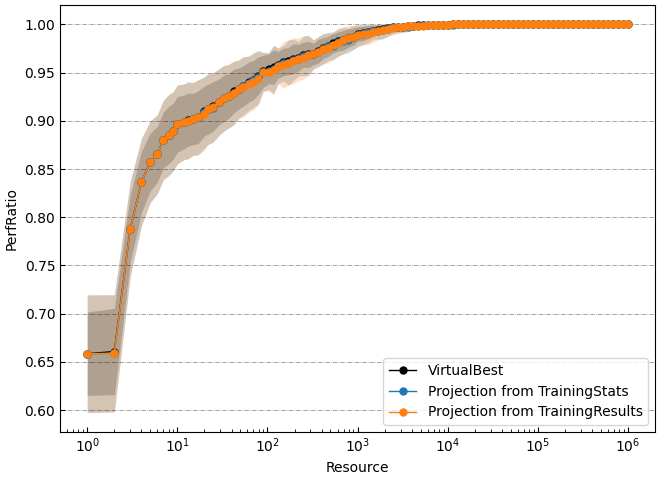

In [18]:
fig, axs = sb.plots.plot_performance()
fig.savefig("performance.png")

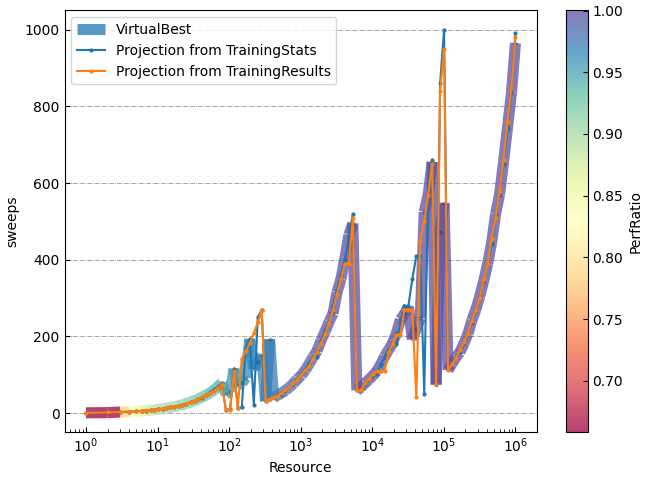

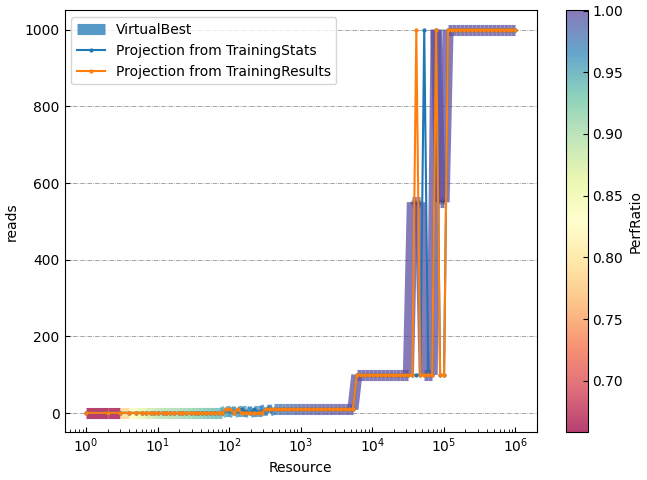

In [19]:
figs, axes = sb.plots.plot_parameters_separate()
for param, fig in figs.items():
    fig.savefig(param + ".png")

### Conclusion

As mentioned before, the initial analysis does not paint the whole picture. From that high-level evaluation, we saw that 1,000 reads per sweep gives us a good performance ratio at a low number of sweeps (22). This corresponds to a 22,000 value for our resource. However, looking at the input recommendation plots, we see that:

- The only moment when it is worth using 1,000 reads is when we have more than $10^5$ available resources.
- We can reach 1.0 performance ratio around a much lower resource value ($10^3$).
- From the first plot, it is noticeable that the confidence interval becomes narrower from resource value $10^3$ and forward.

From the deeper analysis provided by the framework, we can see that there is pretty much no point in ever using 1,000 or even 100 reads per sweep. We should, instead, stick with 1 or 10 reads per sweep, investing, at most, $10^3$ resources.